# Data Clustering

## 1. Import Libraries

In [1]:
import importlib
import sys, os

# Ensure project root is on path
sys.path.insert(0, os.path.abspath(".."))

import src.code.class_pipeline_functions as cpf
import src.code.io_utils as io

importlib.reload(cpf)
importlib.reload(io)

import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 1000)

## 2. Multiple Perspective Approach

 **Approach:** K-Means clustering applied independently across three business perspectives, 
 followed by hierarchical merging of the resulting cluster combinations.

In [2]:
customer = io.load("../data/prepared/customer.parquet")

[LOAD] ../data/prepared/customer.parquet | shape: (134222, 42)


In [ ]:
# Perspective 1 — Contract Financial Profile
p1_cols = ['N_CONTRACTS', 'TOTAL_MTFINO', 
           'TOTAL_MENSALIDADE', 'MEDIAN_DURDEG'] #'MT_MENSAL_MEDIAN'

# Perspective 2 — Risk & External Credit Behaviour
p2_cols = ['MAX_RANGPRO', 'MAX_RANGCLI',"MAX_RISKA", # ver se tiro o MAX_RISKA
           'ALLBD_IDADE_MEAN__N',
           'COUNT_CL_MEDIAN', 'COUNT_AUTO_MEDIAN', 'COUNT_TOTAL_MEDIAN',
           'DIVIDAS_TOTAL_MEDIAN',
           'MONTVENC_TOTAL_LOG', 'RISK_EVER',  'RISK_RECENT'  
            ] 

# Perspective 3 — Cetelem History
p3_cols = ['CLIENT_SENIORITY_YEARS', 'YEARS_SINCE_LAST_CONTRACT', 
           'ALLBD_N_Dossiers__N']

# Profiling variables — not used in clustering, used for segment description only
profiling_cols = [
    # Sociodemographic
    'sdem_age', 'CSP', 'NBENF',
    # Contract antiquity (limited to 2024-2025 window — interpret with caution)
    'ALLBD_IDADE_MEAN__N',
    # Historical risk
    'RISK_TOTAL',
    # Family situation dummies (sdem_SITFAM_F excluded per Cetelem guidance)
    'sdem_SITFAM_D', 'sdem_SITFAM_P', 'sdem_SITFAM_S',
    'sdem_SITFAM_U', 'sdem_SITFAM_Unknown',
    'sdem_SITFAM_V', 'sdem_SITFAM_X',
    # Habitat dummies
    'sdem_HABITAT_A', 'sdem_HABITAT_E', 'sdem_HABITAT_F',
    'sdem_HABITAT_L', 'sdem_HABITAT_O', 'sdem_HABITAT_P',
    'sdem_HABITAT_Unknown', 'sdem_HABITAT_X',
    # Sum of monthly installments paid by the client (66% missing values that were imputed to 0)
    'MT_MENSAL_MEDIAN',
    'MEDIAN_RESSO',
    'EXTERNAL_TO_CETELEM'
]

Three perspectives were defined to capture distinct dimensions of customer behaviour:

**Perspective 1 — Contract Financial Profile**  
Captures the financial weight of the customer's relationship with Cetelem.  
Variables: `N_CONTRACTS`, `TOTAL_MTFINO`, `TOTAL_MENSALIDADE`, `MEDIAN_RESSO`, `MT_MENSAL_MEDIAN`

**Perspective 2 — Risk & External Credit Behaviour** ⚠️  
Captures the customer's broader credit behaviour and delinquency signals.  
Variables: `MAX_RANGPRO`, `MAX_RANGCLI`, `MEDIAN_DURDEG`, `ALLBD_IDADE_MEAN__N`, ...  
> ⚠️ **Note:** `MONTVENC_*` variables had IQR=0 (75%+ zeros). Log1p transform + flag encoding applied. To validate with team.

**Perspective 3 — Cetelem History**  
Captures the depth and recency of the customer's history within Cetelem.  
Variables: `CLIENT_SENIORITY_YEARS`, `MONTHS_SINCE_LAST_CONTRACT`, `ALLBD_N_Dossiers__N`  
> ⚠️ **Note:** Data limited to 2024–2025 window. Seniority and recency metrics reflect relative position within the dataset period, not true customer lifetime.

In [5]:
perspectives = {
    'P1_Financial': p1_cols,
    'P2_Risk': p2_cols,
    'P3_History': p3_cols
}

### 2.1 N-Clusters

Determining the optimal number of clusters for each perspective using two complementary methods:

- **Elbow Method**: identifies the point of diminishing returns in inertia reduction
- **Silhouette Score**: measures how well-separated clusters are (range: -1 to 1)

c:\Users\Asus\anaconda3\envs\Fall2526\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


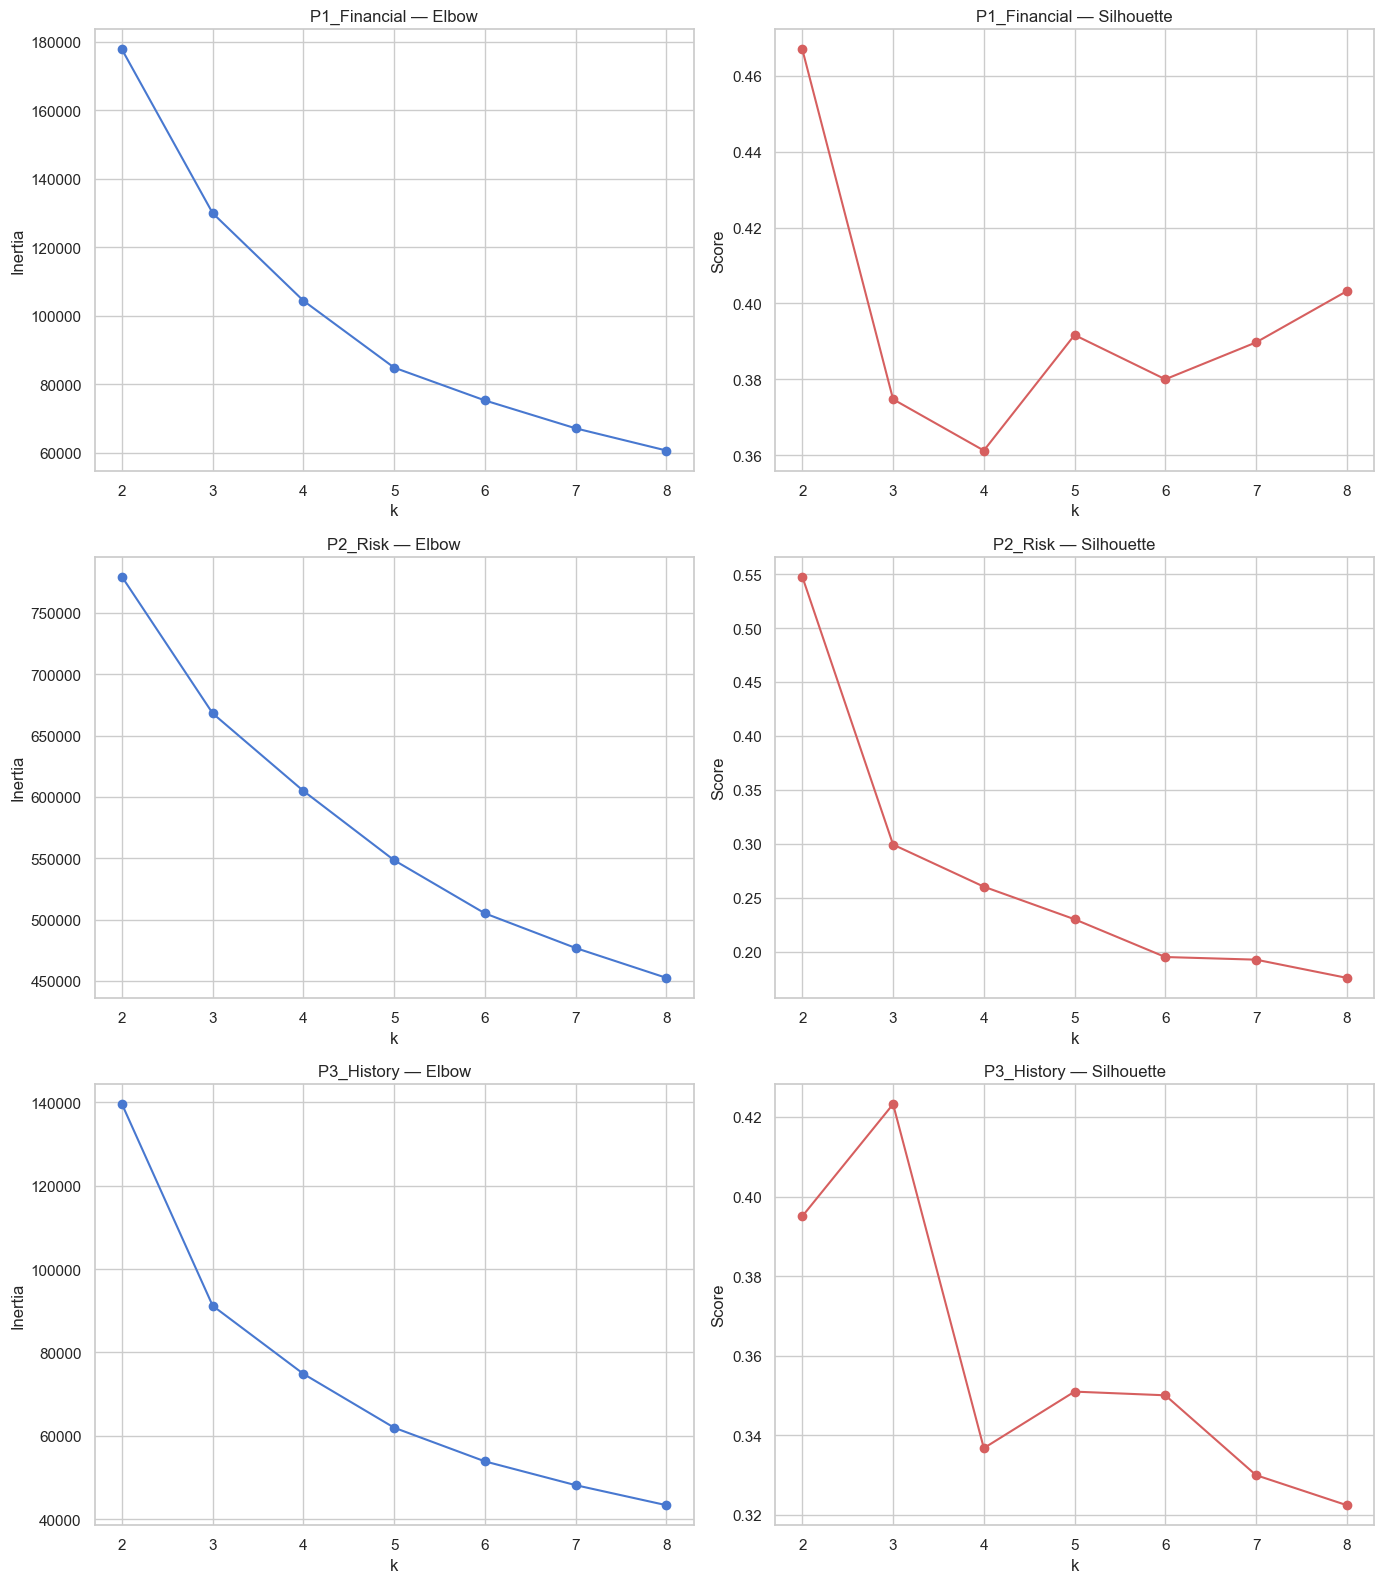

In [6]:
fig, axes = plt.subplots(len(perspectives), 2, figsize=(14, 16))

for idx, (name, cols) in enumerate(perspectives.items()):
    X = customer[cols].dropna()
    inertias, silhouettes = [], []
    K = range(2, 9)
    
    for k in K:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X, km.labels_, sample_size=10000))
    
    axes[idx, 0].plot(K, inertias, 'bo-')
    axes[idx, 0].set_title(f'{name} — Elbow')
    axes[idx, 0].set_xlabel('k')
    axes[idx, 0].set_ylabel('Inertia')
    
    axes[idx, 1].plot(K, silhouettes, 'ro-')
    axes[idx, 1].set_title(f'{name} — Silhouette')
    axes[idx, 1].set_xlabel('k')
    axes[idx, 1].set_ylabel('Score')

plt.tight_layout()
plt.show()

| Perspective | k | Notes |
|-------------|---|-------|
| P1 — Financial Profile | 3 | Elbow + Silhouette agree |
| P2 — Risk & External Credit |  3 | Elbow + Silhouette agree |
| P3 — Cetelem History | 3 | Clear peak at k=4 |

In [7]:
perspectives = {
    'P1_Financial': {'cols': p1_cols, 'k': 3},
    'P2_Risk':      {'cols': p2_cols, 'k': 3}, 
    'P3_History':   {'cols': p3_cols, 'k': 3},
}

### 2.2 K-means Clustering

In [8]:
for name, config in perspectives.items():
    cols = config['cols']
    k    = config['k']
    
    print(f"\n{'='*50}", flush=True)
    print(f"{name} | k={k} | {len(cols)} variáveis", flush=True)
    print(f"{'='*50}", flush=True)
    
    # Verificar nulos
    n_nulls = customer[cols].isnull().sum().sum()
    if n_nulls > 0:
        print(f"  {n_nulls} nulos encontrados — a remover linhas", flush=True)
    
    X = customer[cols].dropna()
    
    # Fit KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    
    # Guardar labels no dataframe
    cluster_col = f'cluster_{name}'
    customer.loc[X.index, cluster_col] = labels
    
    # Distribuição dos clusters
    dist = customer[cluster_col].value_counts().sort_index()
    print("\nDistribuição dos clusters:", flush=True)
    for cluster, count in dist.items():
        pct = count / len(X) * 100
        print(f"  Cluster {int(cluster)}: {count:>6} clientes ({pct:.1f}%)", flush=True)
    
    # Centroides — logo aqui para não perder output
    print("\nCentroides:", flush=True)
    centroids = customer.dropna(subset=[cluster_col]).groupby(cluster_col)[cols].mean().round(3)
    print(centroids.T.to_string(), flush=True)
    
    # Inércia final
    print(f"\nInércia final: {km.inertia_:,.0f}", flush=True)
    print(flush=True)
    sys.stdout.flush()

print("\n Clustering concluído para todas as perspetivas")
print(f"Colunas adicionadas: {[f'cluster_{p}' for p in perspectives.keys()]}")


P1_Financial | k=3 | 4 variáveis

Distribuição dos clusters:
  Cluster 0:  45542 clientes (33.9%)
  Cluster 1:  25987 clientes (19.4%)
  Cluster 2:  62693 clientes (46.7%)

Centroides:
cluster_P1_Financial  0.000  1.000  2.000
N_CONTRACTS           0.167  0.627  0.086
TOTAL_MTFINO         -0.336  1.675  0.120
TOTAL_MENSALIDADE    -0.102  1.666 -0.044
MEDIAN_DURDEG        -1.238  0.132  0.104

Inércia final: 129,955


P2_Risk | k=3 | 11 variáveis

Distribuição dos clusters:
  Cluster 0:  26745 clientes (19.9%)
  Cluster 1:  82918 clientes (61.8%)
  Cluster 2:  24559 clientes (18.3%)

Centroides:
cluster_P2_Risk       0.000  1.000  2.000
MAX_RANGPRO           0.119  0.104  0.110
MAX_RANGCLI           0.078  0.093  0.145
MAX_RISKA             0.139  0.025  0.022
ALLBD_IDADE_MEAN__N   0.067  0.185  0.106
COUNT_CL_MEDIAN       1.007 -0.061  2.048
COUNT_AUTO_MEDIAN     0.544  0.539  0.474
COUNT_TOTAL_MEDIAN    0.130 -0.277  0.705
DIVIDAS_TOTAL_MEDIAN  0.410  0.200  0.938
MONTVENC_TOTAL_LOG 

### 2.3 Merge clusters with Hierarchical Clustering

Each customer receives a combined label `P1_P2_P3` (e.g. `0_0_2`) from the three K-Means runs.  
Ward linkage hierarchical clustering is then applied over the centroids of each combination  
to identify natural groupings and reduce to a final set of actionable segments.


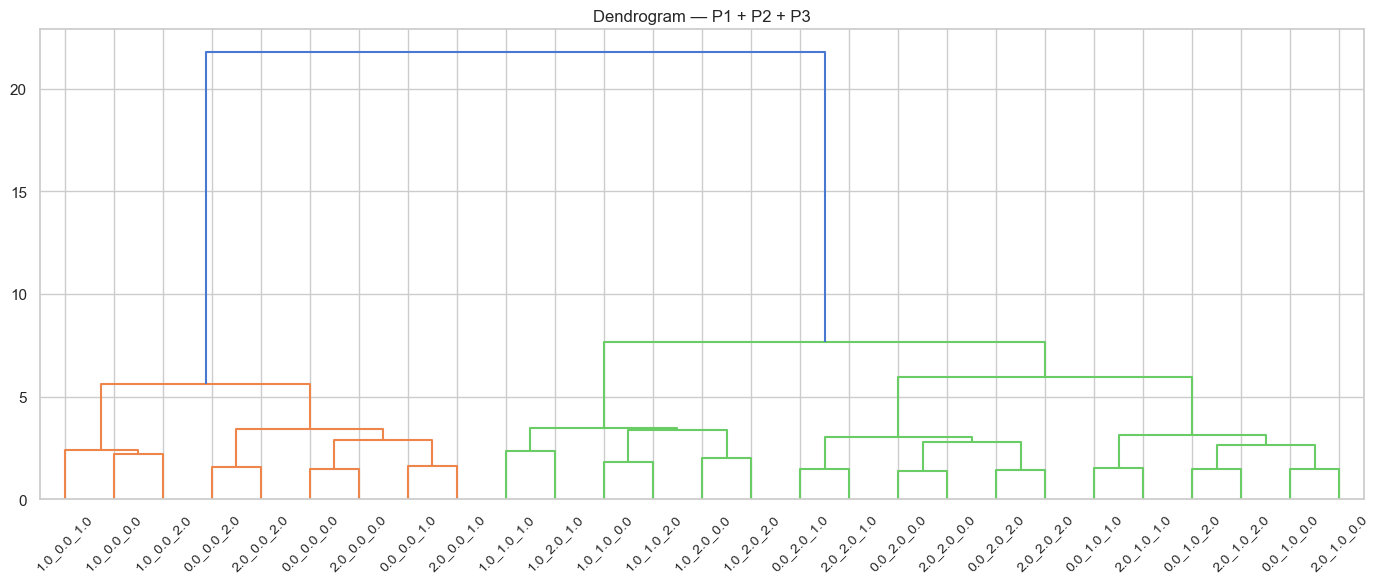

segment_final
1    26745
2    21098
3    18766
4    67613
Name: count, dtype: int64


In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# ── Create combined label ─────────────────────────────────────────────────────
customer['cluster_P1_P2_P3'] = (
    customer['cluster_P1_Financial'].astype(str) + '_' +
    customer['cluster_P2_Risk'].astype(str) + '_' +
    customer['cluster_P3_History'].astype(str)
)

# ── Hierarchical clustering on centroids ──────────────────────────────────────
all_cols = p1_cols + p2_cols + p3_cols
centroids = customer.groupby('cluster_P1_P2_P3')[all_cols].mean()

Z = linkage(centroids, method='ward')

# Dendrogram
plt.figure(figsize=(14, 6))
dendrogram(Z, labels=centroids.index.tolist(), leaf_rotation=45, leaf_font_size=10)
plt.title('Dendrogram — P1 + P2 + P3')
plt.tight_layout()
plt.show()

# ── Final segmentation — adjust n_final after seeing dendrogram ───────────────
n_final = 4

customer['segment_final'] = customer['cluster_P1_P2_P3'].map(
    dict(zip(centroids.index, fcluster(Z, n_final, criterion='maxclust')))
)

print(customer['segment_final'].value_counts().sort_index())

## 3. Profiling

In [20]:
# ── Profiling dos 4 segmentos finais ─────────────────────────────────────────

all_feature_cols = p1_cols + p2_cols + p3_cols

sitfam_cols = ['sdem_SITFAM_D', 'sdem_SITFAM_P', 'sdem_SITFAM_S',
               'sdem_SITFAM_U', 'sdem_SITFAM_Unknown',
               'sdem_SITFAM_V', 'sdem_SITFAM_X']

habitat_cols = ['sdem_HABITAT_A', 'sdem_HABITAT_E', 'sdem_HABITAT_F',
                'sdem_HABITAT_L', 'sdem_HABITAT_O', 'sdem_HABITAT_P',
                'sdem_HABITAT_Unknown', 'sdem_HABITAT_X']

continuous_profiling = ['sdem_age', 'CSP', 'NBENF', 'MEDIAN_RESSO',
                        'ALLBD_IDADE_MEAN__N', 'RISK_TOTAL',
                        'EXTERNAL_TO_CETELEM']

seg_col = 'segment_final'
valid = customer.dropna(subset=[seg_col])
segments = sorted(valid[seg_col].unique())


In [21]:
# ── 1. Distribution ───────────────────────────────────────────────────────────
print("=" * 60)
print("SEGMENT DISTRIBUTION")
print("=" * 60)
for s in segments:
    count = (valid[seg_col] == s).sum()
    pct = count / len(valid) * 100
    print(f"  Segment {int(s)}: {count:>8,} ({pct:.1f}%)")

# ── 2. Feature centroids ──────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("CENTROIDS — CLUSTERING VARIABLES")
print("=" * 60)
centroids_seg = valid.groupby(seg_col)[all_feature_cols].mean().round(3)
print(centroids_seg.T.to_string())

SEGMENT DISTRIBUTION
  Segment 1:   26,745 (19.9%)
  Segment 2:   21,098 (15.7%)
  Segment 3:   18,766 (14.0%)
  Segment 4:   67,613 (50.4%)

CENTROIDS — CLUSTERING VARIABLES
segment_final                  1     2      3      4
N_CONTRACTS                0.180 0.658  0.184  0.105
TOTAL_MTFINO               0.233 1.665 -0.060 -0.066
TOTAL_MENSALIDADE          0.198 1.670 -0.095 -0.042
MEDIAN_DURDEG             -0.260 0.098 -0.371 -0.511
MAX_RANGPRO                0.119 0.253  0.050  0.075
MAX_RANGCLI                0.078 0.258  0.090  0.061
MAX_RISKA                  0.139 0.027  0.021  0.025
ALLBD_IDADE_MEAN__N        0.067 0.115  0.124  0.195
COUNT_CL_MEDIAN            1.007 0.567  2.045 -0.075
COUNT_AUTO_MEDIAN          0.544 0.485  0.482  0.548
COUNT_TOTAL_MEDIAN         0.130 0.047  0.689 -0.289
DIVIDAS_TOTAL_MEDIAN       0.410 0.534  0.904  0.168
MONTVENC_TOTAL_LOG         6.300 0.062  0.096  0.053
RISK_EVER                  0.383 0.036  0.030  0.040
RISK_RECENT                0.1

In [22]:
# ── 3. Continuous profiling ───────────────────────────────────────────────────
print("\n" + "=" * 60)
print("CONTINUOUS PROFILING")
print("=" * 60)
available = [c for c in continuous_profiling if c in valid.columns]
print(f"{'Variable':<25}", end='')
for s in segments:
    print(f"  Seg {int(s):>1}", end='')
print()
print("-" * (25 + len(segments) * 8))
for col in available:
    print(f"  {col:<23}", end='')
    for s in segments:
        val = valid[valid[seg_col] == s][col].mean()
        print(f"  {val:>6.2f}", end='')
    print()


CONTINUOUS PROFILING
Variable                   Seg 1  Seg 2  Seg 3  Seg 4
---------------------------------------------------------
  sdem_age                  -0.06    0.09    0.05    0.05
  CSP                       -0.27   -0.35   -0.39   -0.26
  NBENF                      0.62    0.63    0.70    0.57
  MEDIAN_RESSO               0.11    0.41    0.43    0.08
  ALLBD_IDADE_MEAN__N        0.07    0.12    0.12    0.19
  EXTERNAL_TO_CETELEM        0.24   -0.09    0.76    0.00


In [23]:
# ── 4. SITFAM ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FAMILY SITUATION (% per segment)")
print("=" * 60)
sitfam_avail = [c for c in sitfam_cols if c in valid.columns]
sitfam_profile = valid.groupby(seg_col)[sitfam_avail].mean().mul(100).round(1)
sitfam_profile.columns = [c.replace('sdem_SITFAM_', '') for c in sitfam_avail]
print(sitfam_profile.T.to_string())



FAMILY SITUATION (% per segment)
segment_final      1      2      3      4
D              5.800  6.900  7.300  6.300
P              2.400  1.800  1.500  2.100
S             18.500 17.900 18.300 19.200
U              9.600 10.400  8.800  8.500
Unknown        5.000  2.200  3.900  4.900
V              1.500  1.700  1.300  1.700
X             24.900 14.800 17.900 21.600


In [24]:
# ── 5. HABITAT ────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("HABITAT (% per segment)")
print("=" * 60)
habitat_avail = [c for c in habitat_cols if c in valid.columns]
habitat_profile = valid.groupby(seg_col)[habitat_avail].mean().mul(100).round(1)
habitat_profile.columns = [c.replace('sdem_HABITAT_', '') for c in habitat_avail]
print(habitat_profile.T.to_string())


HABITAT (% per segment)
segment_final      1      2      3      4
A             25.900 32.500 42.700 28.100
E              0.100  0.000  0.100  0.100
F             33.500 27.000 22.400 28.300
L             10.400  7.900  7.300 11.500
O              0.200  0.100  0.100  0.100
P             24.800 30.200 23.400 26.700
Unknown        5.000  2.200  3.900  4.900
X              0.100  0.100  0.100  0.100


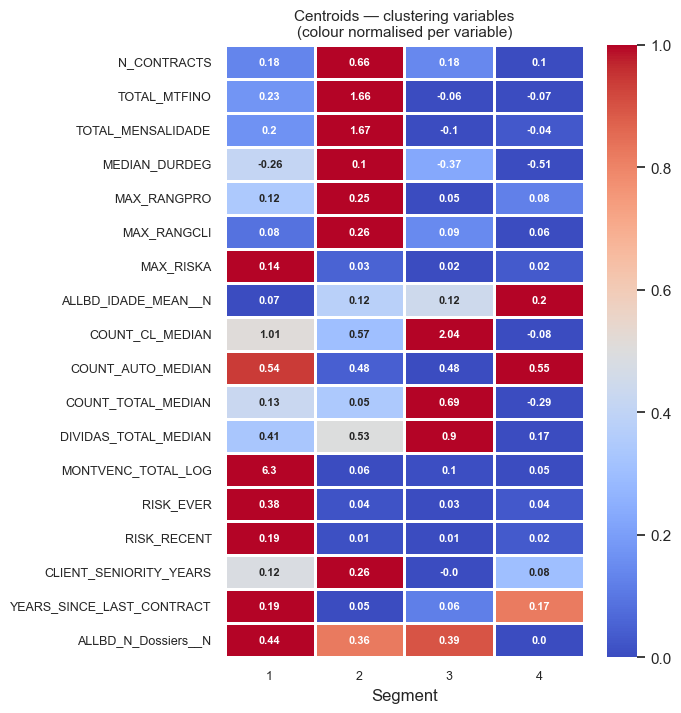

In [43]:
# ── Plot 1 — Centroids (numeric clustering variables) ─────────────────────────
fig, ax = plt.subplots(figsize=(7, len(all_feature_cols) * 0.35 + 1))

centroids_normalized = centroids_seg.copy()
for col in centroids_seg.columns:
    row = centroids_seg[col]
    row_min, row_max = row.min(), row.max()
    if row_max - row_min > 0:
        centroids_normalized[col] = (row - row_min) / (row_max - row_min)
    else:
        centroids_normalized[col] = 0.5

sns.heatmap(centroids_normalized.T, annot=centroids_seg.T.round(2),
            fmt='', cmap='coolwarm', vmin=0, vmax=1,
            ax=ax, linewidths=0.8, linecolor='white',
            annot_kws={'size': 8,'weight': 'bold'})
ax.set_title('Centroids — clustering variables\n(colour normalised per variable)', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)
ax.set_xlabel('Segment')
plt.tight_layout()
plt.show()

Text(0.5, 33.249999999999986, 'Segment')

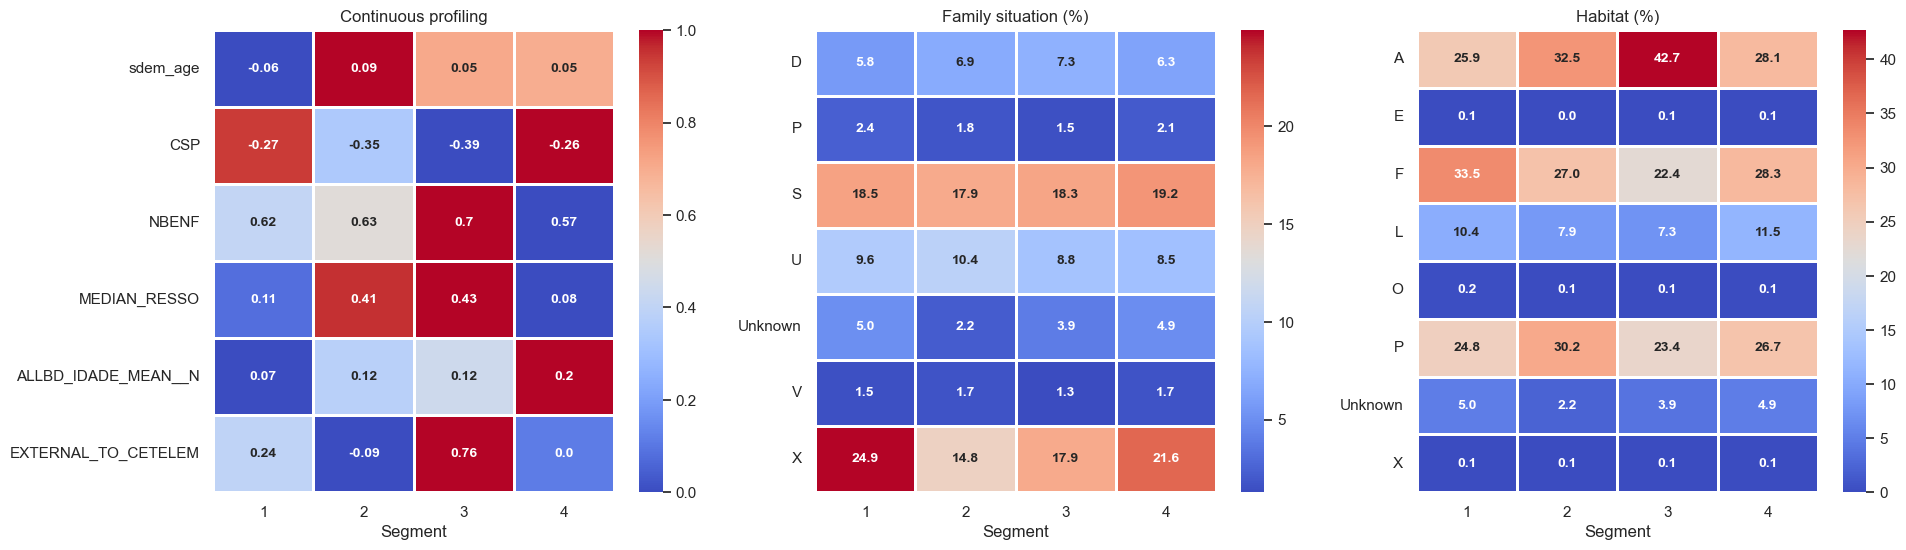

In [37]:
# ── Plot 2 — Continuous profiling + Family situation + Habitat ────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Continuous profiling
available = [c for c in continuous_profiling if c in valid.columns]
profiling_means = valid.groupby(seg_col)[available].mean().round(3)
profiling_normalized = profiling_means.copy()
for col in profiling_means.columns:
    row = profiling_means[col]
    row_min, row_max = row.min(), row.max()
    if row_max - row_min > 0:
        profiling_normalized[col] = (row - row_min) / (row_max - row_min)
    else:
        profiling_normalized[col] = 0.5

sns.heatmap(profiling_normalized.T, annot=profiling_means.T.round(2),
            fmt='', cmap='coolwarm', vmin=0, vmax=1,
            ax=axes[0], linewidths=0.8, linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'})
axes[0].set_title('Continuous profiling')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)
axes[0].set_xlabel('Segment')

# Family situation
sns.heatmap(sitfam_profile.T, annot=True, fmt='.1f', cmap='coolwarm',
            ax=axes[1], linewidths=0.8, linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'})
axes[1].set_title('Family situation (%)')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)
axes[1].set_xlabel('Segment')

# Habitat
sns.heatmap(habitat_profile.T, annot=True, fmt='.1f', cmap='coolwarm',
            ax=axes[2], linewidths=0.8, linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'})
axes[2].set_title('Habitat (%)')
axes[2].set_yticklabels(axes[2].get_yticklabels(), rotation=0)
axes[2].set_xlabel('Segment')